# A walk through feynsage

This notebook goes through the package one step at a time, in the same order as the lecture notes
*Feynman integrals at one loop*. Every step has the code, its output and a diagram.

1. Momenta and a first diagram
2. Spanning trees, 2-forests and the Symanzik polynomials $\mathcal U$, $\mathcal F$
3. The two-loop kite: three independent ways to get $\mathcal U$
4. Zero sectors (Lee's criterion)
5. Integration-by-parts identities
6. Laporta reduction to master integrals
7. The same reduction with finite fields
8. Closed one-loop formulas and the $\epsilon$ expansion
9. Dirac traces with FORM
10. Plots in the style of the notes
11. A real number: the lifetime of the neutral pion

Run it with the SageMath kernel from the top folder of the repository or from `examples/`.

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath('..') if os.path.basename(os.getcwd()) == 'examples' else os.getcwd())
from feynsage import *
from feynsage.plotting import set_theme, draw_panels, draw_sectors, draw_graph, curves, mb_plane, PINK, BLUE
import matplotlib.pyplot as plt
from feynsage.oneloop import *
set_theme()
%matplotlib inline

## 1. Momenta and a first diagram

A momentum is a dictionary: `mom(l=1, p=-1)` is $\ell - p$. The `Kinematics` object fixes the external
momenta, the invariants and the scalar products and whether we are in Euclidean space.

Our first diagram is the bubble with two different masses. The external momentum $p$ enters at vertex A
and leaves at vertex B. Each internal line is `(vertex, vertex, mass^2)`.

lines: 2  vertices: 2  loops L = N - V + 1 = 1


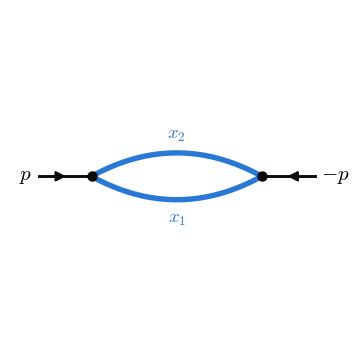

In [2]:
km = Kinematics(['p'], ['pp', 'ma', 'mb'], {('p','p'): 'pp'}, euclidean=True)
bubble = FeynmanGraph([('A','B','ma'), ('A','B','mb')], {'A': mom(p=1), 'B': mom(p=-1)}, km)
print("lines:", bubble.N, " vertices:", bubble.V, " loops L = N - V + 1 =", bubble.L)
bubble.plot();

Massive lines are drawn thick and blue. The label $x_i$ on a line is its Feynman parameter, the same
$x_i$ that appears in $\mathcal U$ and $\mathcal F$.

## 2. Spanning trees, 2-forests, $\mathcal U$ and $\mathcal F$

The rules of the lecture:

* a **spanning tree** touches every vertex and has no loop. Remove $L$ lines to get one.
  $\mathcal U$ is the sum over spanning trees of the product of the $x_i$ of the *removed* lines;
* a **2-forest** is two trees. Remove $L + 1$ lines. $\mathcal F_0$ is the sum over 2-forests of the
  product of the removed $x_i$ times $P^2$, where $P$ is the total external momentum entering one of the two trees;
* $\mathcal F = \mathcal F_0 + \mathcal U \sum_i x_i m_i^2$.

For the bubble, removing either line leaves a tree and removing both leaves two single vertices.

U = x1 + x2
F = ma*x1^2 + (pp + ma + mb)*x1*x2 + mb*x2^2


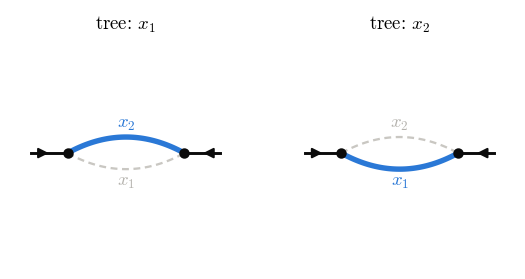

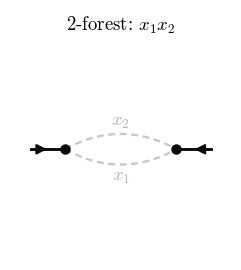

In [3]:
def xs(rem):
    return "$" + "".join("x_{%d}" % (i + 1) for i in rem) + "$"

trees = bubble.spanning_trees()
draw_panels(bubble, trees, titles=["tree: " + xs(r) for r in trees], momenta=False);
forests = bubble.two_forests()
draw_panels(bubble, [r for r, comp in forests], titles=["2-forest: " + xs(r) for r, comp in forests], momenta=False);
print("U =", bubble.U())
print("F =", bubble.F())

The grey dashed lines are the removed ones. $\mathcal U = x_1 + x_2$ has one term per tree and
$\mathcal F_0 = p^2 x_1 x_2$ comes from the one 2-forest, since the momentum entering vertex A is $p$.

## 3. The two-loop kite

Vertices L, T, B, R. The momentum $p$ enters at L and leaves at R and line 5 joins T and B.
We read $\mathcal U$ three ways and check that they agree:

1. from the spanning trees (the rule above);
2. from the Kirchhoff matrix-tree theorem (a determinant of the graph Laplacian);
3. from the matrix method $\mathcal U = \det M$, after routing loop momenta through a cycle basis.

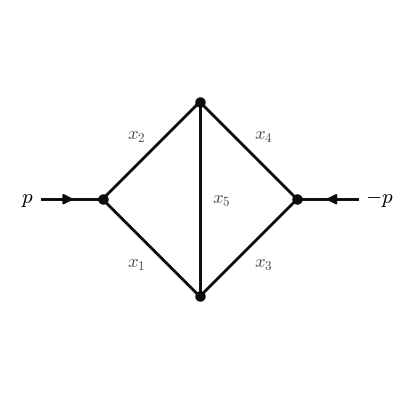

In [4]:
kin = Kinematics(['p'], ['pp'], {('p','p'): 'pp'}, euclidean=True)
kite = FeynmanGraph([('L','B',0), ('L','T',0), ('B','R',0), ('T','R',0), ('T','B',0)],
                    {'L': mom(p=1), 'R': mom(p=-1)}, kin)
kite.plot(figsize=(3.2, 3.2));

8 spanning trees, each with L = 2 lines removed


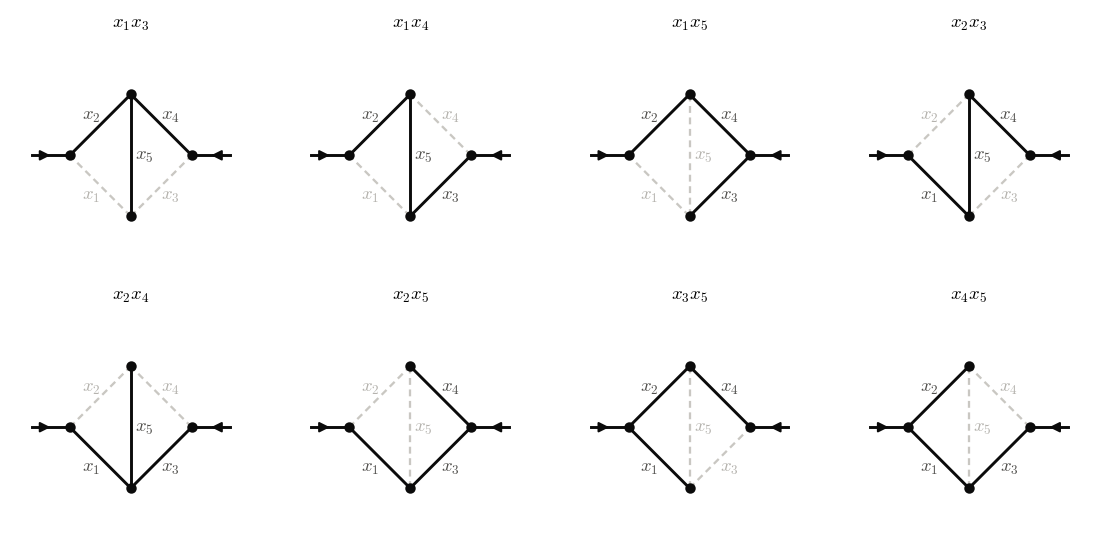

In [5]:
trees = kite.spanning_trees()
print(len(trees), "spanning trees, each with L = 2 lines removed")
draw_panels(kite, trees, titles=[xs(r) for r in trees], momenta=False, ncols=4);

10 2-forests; the title gives the removed lines and the momentum entering one tree


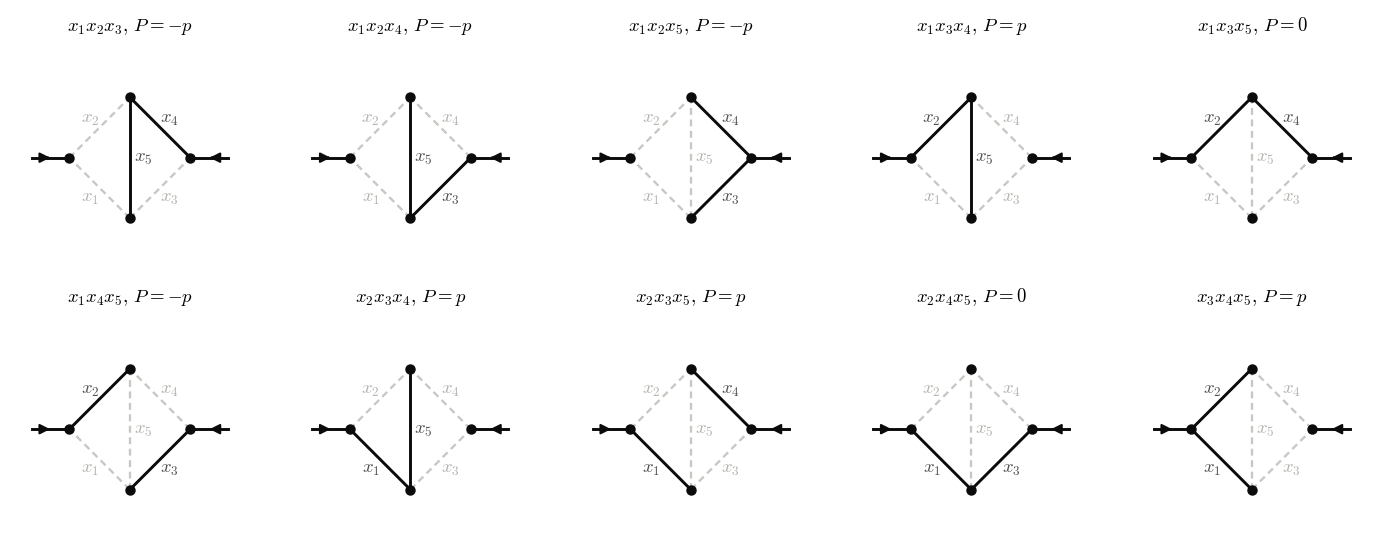

In [6]:
forests = kite.two_forests()
print(len(forests), "2-forests; the title gives the removed lines and the momentum entering one tree")
def entering(comp):
    tot = {}
    for v in comp:
        for k, c in kite.ext.get(v, {}).items():
            tot[k] = tot.get(k, 0) + c
    tot = {k: c for k, c in tot.items() if c}
    return "0" if not tot else "+".join(("" if c == 1 else "-" if c == -1 else str(c)) + k for k, c in tot.items())
draw_panels(kite, [r for r, c in forests],
            titles=[xs(r) + ", $P=" + entering(c) + "$" for r, c in forests], momenta=False, ncols=5);

2-forests in which one tree gets no external momentum ($P = 0$) do not contribute to $\mathcal F_0$.
Now the three ways of computing $\mathcal U$ and $\mathcal F$ from the trees and from the matrix method:

In [7]:
U, F = kite.U(), kite.F()
props, loops = kite.family()
fam = IntegralFamily('kite', loops, kin, props)
Um, Fm = fam.UF()
print("U (trees)     =", U)
print("U (Kirchhoff) =", kite.U_kirchhoff(), "  same:", kite.U_kirchhoff() == U)
print("U (det M)     =", Um, "  same:", kite.R(str(Um)) == U)
print("F (2-forests) =", F)
print("F (matrix)    same:", kite.R(str(Fm)) == F)

U (trees)     = x1*x3 + x2*x3 + x1*x4 + x2*x4 + x1*x5 + x2*x5 + x3*x5 + x4*x5
U (Kirchhoff) = x1*x3 + x2*x3 + x1*x4 + x2*x4 + x1*x5 + x2*x5 + x3*x5 + x4*x5   same: True
U (det M)     = x1*x3 + x2*x3 + x1*x4 + x2*x4 + x1*x5 + x2*x5 + x3*x5 + x4*x5   same: True
F (2-forests) = pp*x1*x2*x3 + pp*x1*x2*x4 + pp*x1*x3*x4 + pp*x2*x3*x4 + pp*x1*x2*x5 + pp*x2*x3*x5 + pp*x1*x4*x5 + pp*x3*x4*x5
F (matrix)    same: True


## 4. Zero sectors

Setting some indices to 0 gives a *sector*. An index 0 means the propagator is absent, so in the
picture that line is **shrunk to a point** and its two end vertices merge (this is different from the
spanning trees above, where lines are deleted). A sector whose integrals are scaleless is zero in
dimensional regularisation. Lee's criterion decides this from $\mathcal U + \mathcal F$ alone: the sector is
zero if and only if a vector $k$ exists with $\langle k, e\rangle = 1$ for every exponent vector $e$ of
$\mathcal U + \mathcal F$.

Here is the massless kite with $p^2 = q^2$ in Minkowski space, the family used for the reduction below.
We list every sector with 3 lines and draw all of them.

In [8]:
kq = Kinematics(['q'], [], {('q','q'): 1}, euclidean=False)          # q^2 = 1, the only scale
props_q = [(mom(l1=1),0), (mom(l1=1,q=1),0), (mom(l1=1,l2=1),0), (mom(l1=1,l2=1,q=1),0), (mom(l2=1),0)]
famq = IntegralFamily('kite', ['l1','l2'], kq, props_q)
from itertools import combinations
three = [s for s in [tuple(1 if i in c else 0 for i in range(5)) for c in combinations(range(5), 3)]]
zero = [s for s in three if famq.is_zero_sector(s)]
for s in three:
    print(s, "zero" if s in zero else "non-zero")

(1, 1, 1, 0, 0) zero
(1, 1, 0, 1, 0) zero
(1, 1, 0, 0, 1) zero
(1, 0, 1, 1, 0) zero
(1, 0, 1, 0, 1) zero
(1, 0, 0, 1, 1) non-zero
(0, 1, 1, 1, 0) zero
(0, 1, 1, 0, 1) non-zero
(0, 1, 0, 1, 1) zero
(0, 0, 1, 1, 1) zero


To draw a sector we need to know which propagator is which line. We write down a kite graph with the
lines in the order of the propagators and check that it has the same $\mathcal U$ and $\mathcal F$ as the
family. If the order were wrong, the polynomials would not match. Following the momentum through the
vertices, $\ell_1$ runs on L–B, $\ell_1 + q$ on L–T, $\ell_1 + \ell_2$ on B–R, $\ell_1 + \ell_2 + q$ on T–R and
$\ell_2$ on T–B.

same U: True   same F: True


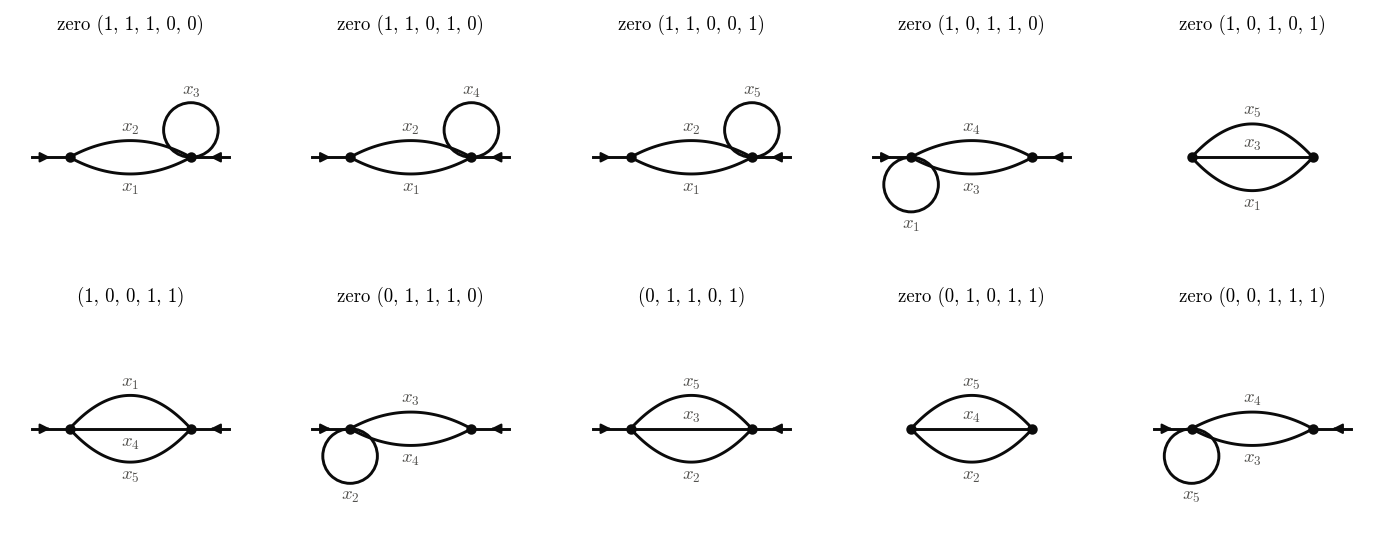

In [9]:
kiteq = FeynmanGraph([('L','B',0), ('L','T',0), ('B','R',0), ('T','R',0), ('T','B',0)],
                     {'L': mom(q=1), 'R': mom(q=-1)}, kq)
# check that this graph has the same U and F as the family, so the line order is right
Ug, Fg = kiteq.U(), kiteq.F()
Uf, Ff = famq.UF()
print("same U:", kiteq.R(str(Uf)) == Ug, "  same F:", kiteq.R(str(Ff)) == Fg)
draw_sectors(kiteq, three, titles=[("zero " if s in zero else "") + str(s) for s in three], momenta=False, ncols=5);

A zero sector always contains a massless loop that sits on a single vertex or that no external momentum
flows through: a scaleless tadpole. The non-zero ones are those where $q$ still flows through every loop.

## 5. Integration-by-parts identities

For the one-loop bubble with equal masses in Minkowski space,
$J(a_1, a_2) = \int [d\ell]\, D_1^{-a_1} D_2^{-a_2}$ with $D_1 = \ell^2 - m^2$ and $D_2 = (\ell - p)^2 - m^2$ ($m^2 = 1$).
`fam.ibp(a)` returns the $L(L+E) = 2$ identities $\int \partial_\ell \cdot v \,(\dots) = 0$ for $v = \ell, p$,
as dictionaries {index vector: coefficient}.

identity 1 : (d - 3) J(1, 1) + (-2) J(2, 1) + (s - 2) J(1, 2) + (-1) J(0, 2) = 0
identity 2 : (-s) J(2, 1) + (1) J(2, 0) + (s) J(1, 2) + (-1) J(0, 2) = 0


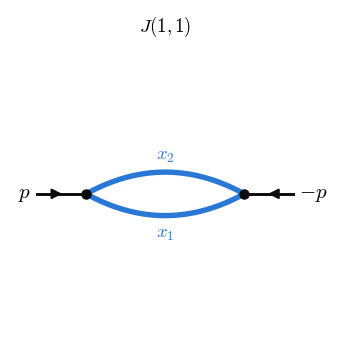

In [10]:
kb = Kinematics(['p'], ['s'], {('p','p'): 's'}, euclidean=False)
d, s = kb.R.gens()
bub = IntegralFamily('bub', ['l'], kb, [(mom(l=1), 1), (mom(l=1, p=-1), 1)])
for k, ident in enumerate(bub.ibp((1, 1))):
    print("identity", k + 1, ":", " + ".join("(%s) J%s" % (c, a) for a, c in ident.items()), "= 0")
gb = FeynmanGraph([('A','B',1), ('A','B',1)], {'A': mom(p=1), 'B': mom(p=-1)}, kb)
gb.plot(figsize=(2.6, 2.6), title="$J(1,1)$");

## 6. Laporta reduction

`Reducer` generates the identities for many seeds, orders the integrals from complicated to simple and
solves. The symmetry $\ell \to p - \ell$ swaps the two lines. What is left unsolved are the master integrals.
In the pictures a pink dot on a line means one more power of that propagator, as in the notes.

masters: [(0, 1), (1, 1)]
J(2, 1) = [(-1) * (s - 4)^-1 * (d - 3)] J(1, 1) + [(1/2) * (s - 4)^-1 * (d - 2)] J(0, 1)
J(2, 2) = [(s - 4)^-2 * s^-1 * (d - 3) * (d*s - 6*s + 4)] J(1, 1) + [(s - 4)^-2 * s^-1 * (-2*d + s + 6) * (d - 2)] J(0, 1)


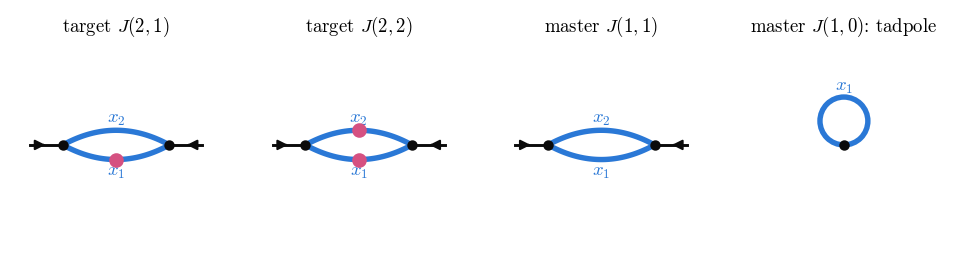

In [11]:
red = Reducer(bub, symmetries=[(1, 0)]).run(rmax=3)
print("masters:", red.masters())
for a in [(2, 1), (2, 2)]:
    print("J%s =" % (a,), " + ".join("[%s] J%s" % (c.factor(), m) for m, c in red.reduce(a).items()))
fig, axes = plt.subplots(1, 4, figsize=(8, 2))
draw_graph(gb, dots={1: 1}, ax=axes[0], momenta=False, title="target $J(2,1)$")
draw_graph(gb, dots={1: 1, 2: 1}, ax=axes[1], momenta=False, title="target $J(2,2)$")
draw_graph(gb, ax=axes[2], momenta=False, title="master $J(1,1)$")
tad, kept = gb.contract([2])
draw_graph(tad, names=kept, ax=axes[3], momenta=False, title="master $J(1,0)$: tadpole");

These agree with Kira 3.1 (see `tests/test_bubble.sage`).

## 7. The same reduction with finite fields

`reduce_ff` does what FIRE and Kira do. It solves the system numerically modulo large primes at random
values of $d$, keeps only the equations the targets need and rebuilds the rational coefficients by
Thiele interpolation and rational reconstruction. Here it is on the kite, for an integral with nine dots,
compared with the exact reducer on a smaller one.

In [12]:
redq = Reducer(famq, symmetries=[(2,3,0,1,4), (1,0,3,2,4)])
t0 = time.time()
res = reduce_ff(redq, [(3,3,2,3,3), (2,2,1,2,2)], rmax=9, smax=4, verbose=True)
print("finite-field time: %.1f s" % (time.time() - t0))
for m, c in res[(2,2,1,2,2)].items():
    print("F(2,2,1,2,2) ->", m, ":", c.factor())

system: 157843 equations, 11462 integrals (0.9s)


primes used: 3, total 2.7s
finite-field time: 2.7 s
F(2,2,1,2,2) -> (0, 1, 1, 0, 1) : (-729) * (d - 8)^-2 * (d - 10)^-1 * (d - 4)^-1 * (d - 7) * (d - 16/3) * (d - 14/3) * (d - 10/3) * (d - 8/3) * (d^2 - 11*d + 20)
F(2,2,1,2,2) -> (1, 1, 1, 1, 0) : (-4) * (d - 8)^-1 * (d - 9) * (d - 6) * (d - 5) * (d - 3)


exact reducer (smaller seed range) time: 7.4 s
same coefficients: True


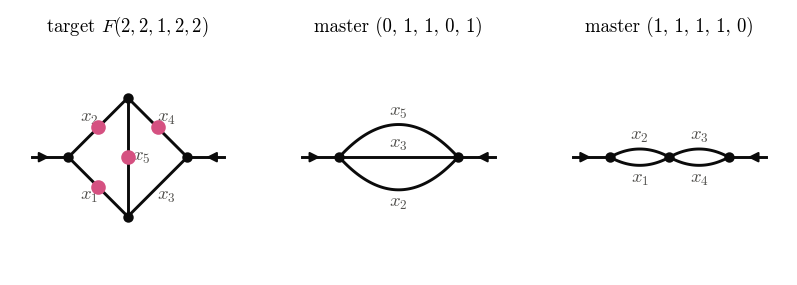

In [13]:
t0 = time.time()
exact = Reducer(famq, symmetries=[(2,3,0,1,4), (1,0,3,2,4)]).run(rmax=4, smax=2)
print("exact reducer (smaller seed range) time: %.1f s" % (time.time() - t0))
print("same coefficients:", all(exact.reduce((2,2,1,2,2))[m] == c for m, c in res[(2,2,1,2,2)].items()))
fig, axes = plt.subplots(1, 3, figsize=(6.6, 2.2))
draw_graph(kiteq, dots={1: 1, 2: 1, 4: 1, 5: 1}, ax=axes[0], momenta=False, title="target $F(2,2,1,2,2)$")
for ax, sec in zip(axes[1:], [(0,1,1,0,1), (1,1,1,1,0)]):
    h, kept = kiteq.contract([i + 1 for i in range(5) if not sec[i]])
    draw_graph(h, names=kept, ax=ax, momenta=False, title="master " + str(sec))

Shrinking lines 1 and 4 of the kite leaves three lines between two vertices, the sunset. Shrinking line 5
glues the two bubbles together at one vertex, so the second master is a product of two one-loop bubbles.

## 8. Closed one-loop formulas and the $\epsilon$ expansion

The module `oneloop` has the tadpole, the massless bubble $G(a, b)$, the on-shell triangle and the
massive bubbles in closed form, with $D = 4 - 2\epsilon$. `expand_eps` makes the Gamma-function poles
explicit before expanding.

As an example, the two-loop $\phi^4$ diagram of the notes is a massless bubble inserted into a triangle:
$G(1,1) \times T(1, 1, 2 - D/2)$.

U = x1*x3 + x2*x3 + x1*x4 + x2*x4 + x3*x4    F = Q2*x1*x2*x3 + Q2*x1*x2*x4


value (Q^2 = 1): 1/12*((pi^2 + 114)*eps^2 + 30*eps + 6)/eps^2
tadpole with one propagator and m^2 = 1: gamma(-1/2*D + 1)


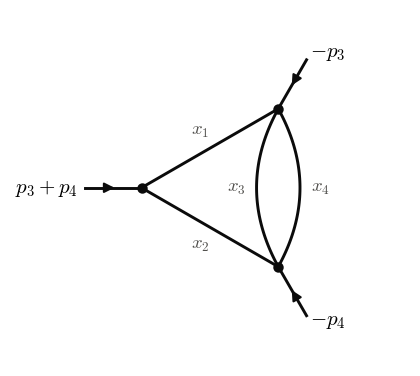

In [14]:
kf = Kinematics(['p3','p4'], ['Q2'], {('p3','p3'):0, ('p4','p4'):0, ('p3','p4'):'Q2/2'}, euclidean=True)
phi4 = FeynmanGraph([('A','B',0), ('A','C',0), ('B','C',0), ('B','C',0)],
                    {'A': mom(p3=1, p4=1), 'B': mom(p3=-1), 'C': mom(p4=-1)}, kf)
phi4.plot(figsize=(3, 3));
print("U =", phi4.U(), "   F =", phi4.F())
val = expand_eps(G(1,1) * triangle_onshell(1, 1, 2 - D/2, 1), 0, loops=2)
print("value (Q^2 = 1):", val)
print("tadpole with one propagator and m^2 = 1:", tadpole(1, 1))

## 9. Dirac traces with FORM

`form.trace` sends the trace to FORM (it must be on the `PATH`) and brings the answer back into Sage.

In [15]:
print(form.trace(['mu', 'nu', 'rho', 'sigma']))

4*g(mu, sigma)*g(nu, rho) - 4*g(mu, rho)*g(nu, sigma) + 4*g(mu, nu)*g(rho, sigma)


## 10. Plots in the style of the notes
11. A real number: the lifetime of the neutral pion

After `set_theme()` every matplotlib and Sage plot uses the fonts and colours of the notes.
`curves` draws several functions together and `mb_plane` draws the poles of a Mellin-Barnes integrand.

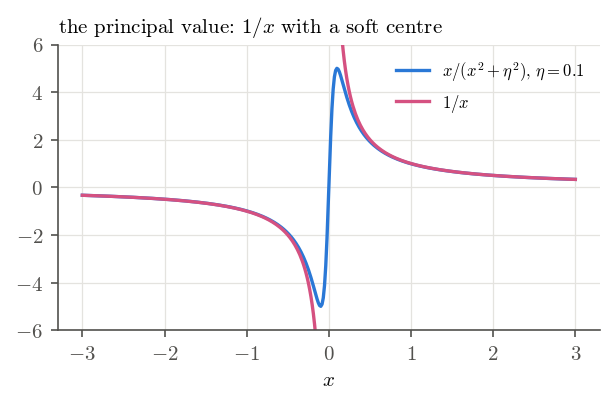

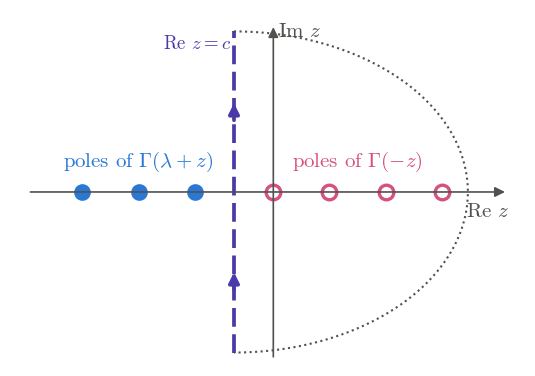

In [16]:
x = var('x')
curves([x/(x^2 + 0.1^2), 1/x], (-3, 3), labels=[r'$x/(x^2+\eta^2)$, $\eta = 0.1$', '$1/x$'], ylim=(-6, 6),
       title="the principal value: $1/x$ with a soft centre");
mb_plane([-1.4, -2.4, -3.4], [0, 1, 2, 3], -0.7, r'$\Gamma(\lambda+z)$', r'$\Gamma(-z)$', close='right');

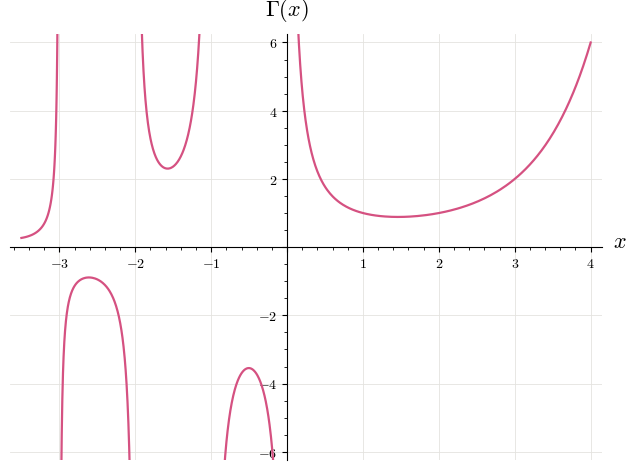

In [17]:
plot(gamma(x), (x, -3.5, 4), ymin=-6, ymax=6, color=PINK, thickness=1.6, detect_poles=True,
     axes_labels=['$x$', r'$\Gamma(x)$'], frame=False)

## 11. A real number: the lifetime of the neutral pion

The $\pi^0$ decays into two photons through a triangle of quarks and its lifetime has been measured to about
one per cent. Here is the whole prediction with the tools above. The physics is explained step by step in
the section *From a loop to a lifetime* of the notes.

The quarks $u$, $d$ (charges $2/3$, $-1/3$, $N_c$ colours) couple to the pion with $g\,\bar q\, i\gamma_5\tau_3\, q\,\pi^0$
and $g = m/f_\pi$. There are two diagrams per quark (the photons in either order). Below is the first one, drawn
by feynsage: a triangle of massive quark lines with the pion momentum entering at one corner.

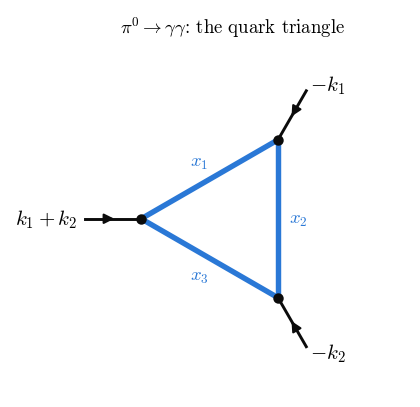

In [18]:
kp = Kinematics(['k1', 'k2'], ['mq'], {('k1','k1'): 0, ('k2','k2'): 0, ('k1','k2'): '1/2'}, euclidean=False)
tri = FeynmanGraph([('P','A','mq'), ('A','B','mq'), ('B','P','mq')],
                   {'P': mom(k1=1, k2=1), 'A': mom(k1=-1), 'B': mom(k2=-1)}, kp)
tri.plot(figsize=(3, 3), title=r"$\pi^0 \to \gamma\gamma$: the quark triangle");

**Step 1, the trace.** A trace with $\gamma_5$ needs at least four other gamma matrices, so only the terms with
exactly one quark mass survive. FORM does it, with the loop momentum already shifted to
$\ell = q - x k_1 + y k_2$ (the Feynman shift of step 2):

In [19]:
T = form.dirac_trace(['g5', 'q - x*k1 + y*k2 + m', 'mu', 'q + (1-x)*k1 + y*k2 + m', 'nu',
                      'q - x*k1 - (1-y)*k2 + m'], vectors=['q', 'k1', 'k2'])
print("Tr =", T, "   (FORM's eps is -i times the usual epsilon)")

Tr = 4*m*eps(k1, k2, mu, nu)    (FORM's eps is -i times the usual epsilon)


Nothing depends on $q$, $x$ or $y$, so the numerator is the constant $4m\,\epsilon^{\mu\nu k_1 k_2}$ and what is left
is the scalar triangle.

**Step 2, the integral.** With Feynman parameters the triangle gives $\Delta = m^2 - xy\,m_\pi^2$ and

$$\int \frac{d^4\ell}{(2\pi)^4}\frac{1}{D_1D_2D_3} = \frac{-i}{16\pi^2 m^2}\, I(r), \qquad I(r) = \int_0^1\! dx\int_0^{1-x}\! dy\, \frac{1}{1 - xy\,r}, \qquad r = \frac{m_\pi^2}{m^2}$$

Expanding $1/(1 - xyr)$ in powers of $r$ gives $I(r) = \sum_n r^n\, n!^2/(2n+2)!$ term by term. We check that this is
$(2/r)\arcsin^2(\sqrt r/2)$ and that the heavy-quark limit is $1/2$.

In [20]:
r, x, y = var('r x y')
n = 12
term_by_term = sum(r^k * integrate(integrate((x*y)^k, y, 0, 1 - x), x, 0, 1) for k in range(n))
closed = 2/r * arcsin(sqrt(r)/2)^2
print("series of the integral:", term_by_term.series(r, 4))
sv = var('s')                                   # r = 4 s^2 makes the closed form analytic in s
diff = (closed.subs(r=4*sv^2).taylor(sv, 0, 2*n - 2) - term_by_term.subs(r=4*sv^2)).expand()
print("closed form minus series, up to r^%d:" % (n - 1), diff)
print("heavy quark limit:", limit(closed, r=0))

series of the integral: 1/2 + 1/24*r + 1/180*r^2 + 1/1120*r^3 + Order(r^4)
closed form minus series, up to r^11: 0
heavy quark limit: 1/2


**Step 3, the amplitude.** One diagram gives $N_c\,(eQ)^2\, g \cdot 4m \cdot I/(16\pi^2 m^2)$, the crossed one the same.
With $g = m/f_\pi$ the quark mass cancels. For $m \gg m_\pi$ ($2I \to 1$) and $e^2 = 4\pi\alpha$ the $u$ and $d$
quarks give $A = N_c (Q_u^2 - Q_d^2)\, e^2/(4\pi^2 f_\pi)$.

**Step 4, the rate.** The polarisation sum gives $2(k_1\cdot k_2)^2 = m_\pi^4/2$, two-body phase space is
$1/(8\pi)$ and the photons are identical (a factor $1/2$), so $\Gamma = A^2 m_\pi^3/(64\pi)$.

In [21]:
Nc, alpha, f, mpi = var('N_c alpha f m_pi')
e2 = 4*pi*alpha
A = Nc * ((2/3)^2 - (-1/3)^2) * e2 / (4*pi^2*f)
Gamma = (A^2 * mpi^3 / (64*pi)).simplify_full()
print("Gamma =", Gamma)
vals = {alpha: 1/137.035999, mpi: 134.9768, f: 130.2/sqrt(2)}      # MeV
hbar, BR = 6.582119569e-22, 0.98823                                  # MeV s, BR(gamma gamma)
G3 = (Gamma.subs(vals).subs({Nc: 3}) * 1e6).n()                         # eV
print("Gamma(pi0 -> gamma gamma) = %.2f eV     PrimEx-II (2020): 7.80 +- 0.12 eV" % G3)
print("lifetime = %.3g s          PDG: (8.43 +- 0.13)e-17 s" % (hbar * 1e6 * BR / G3))
print("with one colour: Gamma = %.2f eV, nine times too small" % (Gamma.subs(vals).subs({Nc: 1}) * 1e6).n())
print("finite constituent mass m = 330 MeV: 2 I(r) = %.4f" % (2*closed.subs(r=(134.9768/330)^2)).n())

Gamma = 1/576*N_c^2*alpha^2*m_pi^3/(pi^3*f^2)
Gamma(pi0 -> gamma gamma) = 7.79 eV     PrimEx-II (2020): 7.80 +- 0.12 eV
lifetime = 8.35e-17 s          PDG: (8.43 +- 0.13)e-17 s
with one colour: Gamma = 0.87 eV, nine times too small
finite constituent mass m = 330 MeV: 2 I(r) = 1.0143


One triangle of quarks gives the lifetime of the pion to about one per cent. The rate grows as $N_c^2$, so the
measurement also tells us that quarks come in three colours.